In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


In [11]:
df = pd.read_csv('polynomial_data.csv')

In [12]:
X = df['x_train'].values.reshape(-1,1)
y = df['y_train'].values.reshape(-1,1)

In [28]:
X_mean,X_std = X.mean(),X.std()
y_mean,y_std = y.mean(),y.std()
X_scaled=(X-X_mean)/X_std
y_scaled=(y-y_mean)/y_std

In [29]:
X_tensor=torch.tensor(X_scaled,dtype= torch.float32)
y_tensor=torch.tensor(y_scaled,dtype= torch.float32)

In [30]:
model = nn.Sequential(
    nn.Linear(1,64),
    nn.ReLU(),
    nn.Linear(64,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)

In [39]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [40]:
print("Training the Pytorch model on 'Polynomial_data.csv'...")
epochs=500
for epochs in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs,y_tensor)
    loss.backward()
    optimizer.step()

    if (epochs + 1) %100 == 0:
        print(f'Epoch [{epochs+1}/{epochs}],Loss:{loss.item():4f}')
print("training complete \n ")

Training the Pytorch model on 'Polynomial_data.csv'...
Epoch [100/99],Loss:0.013795
Epoch [200/199],Loss:0.013641
Epoch [300/299],Loss:0.013463
Epoch [400/399],Loss:0.013318
Epoch [500/499],Loss:0.013204
training complete 
 


In [41]:
model.eval()

Sequential(
  (0): Linear(in_features=1, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)

In [42]:
with torch.no_grad():
    y_pred_scaled = model(X_tensor).numpy()
y_pred = (y_pred_scaled*y_std)+y_mean

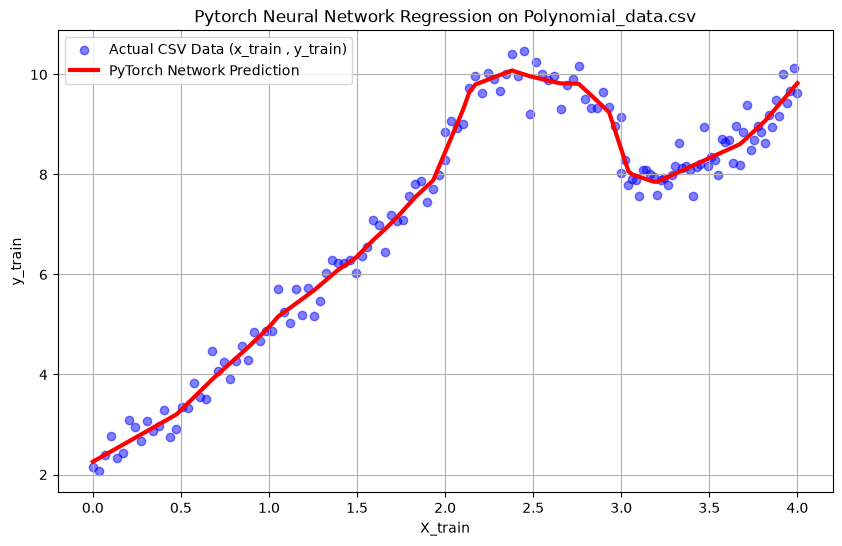

In [47]:
plt.figure(figsize=(10,6))
plt.scatter(X,y,color='blue',label='Actual CSV Data (x_train , y_train)',alpha=0.5)

sort_axis = np.argsort(X[:,0])
plt.plot(X[sort_axis], y_pred[sort_axis], color='red', linewidth=3, label='PyTorch Network Prediction')
plt.title('Pytorch Neural Network Regression on Polynomial_data.csv')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.legend()
plt.grid(True)
plt.show()

Training the PyTorch model from scratch and tracking loss...
Epoch [100/500], Loss: 0.0215
Epoch [200/500], Loss: 0.0148
Epoch [300/500], Loss: 0.0135
Epoch [400/500], Loss: 0.0133
Epoch [500/500], Loss: 0.0134
Training complete!



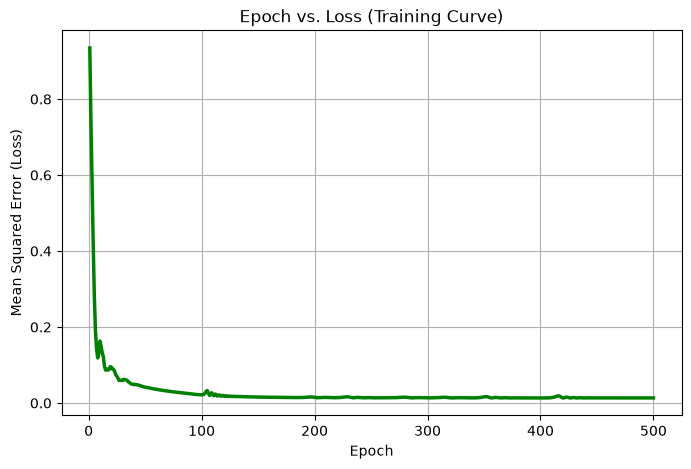

In [44]:
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.005) 

print("Training the PyTorch model from scratch and tracking loss...")
epochs_count = 500 
losses = [] 

for epoch in range(epochs_count):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs_count}], Loss: {loss.item():.4f}')

print("Training complete!\n")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_count + 1), losses, color='green', linewidth=2.5)
plt.title('Epoch vs. Loss (Training Curve)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()